# NYC Demand Zones — Entrenamiento del modelo no supervisado

**Proyecto de la Segunda Unidad — Aprendizaje de Máquina, IX ciclo grupo B**
Universidad Nacional del Altiplano Puno — Ingeniería de Sistemas

---

## Objetivo

Descubrir, **sin etiquetas**, las zonas de concentración de demanda de viajes en
Nueva York a partir de las coordenadas de recogida, y dejar el modelo listo para
operar en producción con reentrenamiento automatizado.

## Dataset

`Uber Pickups in New York City` (Kaggle / FiveThirtyEight). Seis archivos
mensuales de abril a septiembre de 2014, con columnas `Date/Time`, `Lat`, `Lon`
y `Base`.

| Partición | Meses | Rol |
|---|---|---|
| Entrenamiento inicial | `apr14`, `may14` | Modelo que sale a producción |
| Lotes de producción | `jun14` … `sep14` | "El futuro" que llega mes a mes |

## Decisión de diseño central

**Solo `Lat` y `Lon` entran al modelo.** La marca de tiempo no es una
característica: mezclar grados geográficos con horas deforma la métrica de
distancia y produce grupos sin sentido físico. La hora se usa *después* del
clustering, para construir el perfil horario de cada zona descubierta.

In [1]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

sys.path.append("..")           # para importar el paquete src/
from src import data as D
from src.train import evaluate, fit_final, search_k

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (11, 5)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Entorno listo.")

Entorno listo.


## 1. Carga y limpieza

Si los CSV de Kaggle no están en `data/raw/`, el notebook cae en un generador
sintético para que todo pueda ejecutarse igual. Ese mismo generador es el que usa
la suite de pruebas en GitHub Actions, donde no hay credenciales de Kaggle.

In [2]:
USE_SYNTHETIC = not any(D.RAW_DIR.glob("uber-raw-data-*.csv"))

if USE_SYNTHETIC:
    print("⚠️  No se encontraron los CSV de Kaggle. Usando datos sintéticos.")
    print("    Descarga: kaggle datasets download -d fivethirtyeight/uber-pickups-in-new-york-city")
    df = D.make_synthetic_batch(80_000, n_zones=12, seed=RANDOM_STATE)
else:
    df = D.load_months(D.TRAIN_MONTHS, sample=400_000, seed=RANDOM_STATE)

print(f"Registros tras limpieza y muestreo: {len(df):,}")
df.head()

⚠️  No se encontraron los CSV de Kaggle. Usando datos sintéticos.
    Descarga: kaggle datasets download -d fivethirtyeight/uber-pickups-in-new-york-city
Registros tras limpieza y muestreo: 80,000


,Lat,Lon,ts,hour,dow
0,40.572480,-74.269713,2014-04-08 14:10:00,14,1
1,40.678640,-74.040743,2014-04-18 01:33:00,1,4
2,40.830443,-74.165851,2014-04-30 19:33:00,19,2
3,40.868931,-74.260882,2014-04-18 08:24:00,8,4
4,40.856955,-74.241326,2014-04-23 03:13:00,3,2


### Qué hace exactamente la limpieza

1. Elimina filas con `Lat`/`Lon` nulos.
2. **Recorta al bounding box de NYC** (lat 40.50–41.00, lon −74.30 a −73.70).
   Hay registros en (0, 0) que, de no filtrarse, arrastran los centroides hacia
   el Golfo de Guinea y arruinan el modelo entero.
3. Deriva `hour` y `dow` desde la marca de tiempo — para el perfil, no para el modelo.

In [3]:
print("Rango latitud :", df.Lat.min().round(4), "→", df.Lat.max().round(4))
print("Rango longitud:", df.Lon.min().round(4), "→", df.Lon.max().round(4))
df[["Lat", "Lon"]].describe().T

Rango latitud : 40.5232 → 40.938
Rango longitud: -74.2899 → -73.7324


,count,mean,std,min,25%,50%,75%,max
Lat,80000.0,40.780355,0.114490,40.523202,40.742244,40.811994,40.875054,40.938029
Lon,80000.0,-74.049522,0.166082,-74.289893,-74.211206,-74.063081,-73.906885,-73.732391


## 2. Análisis exploratorio

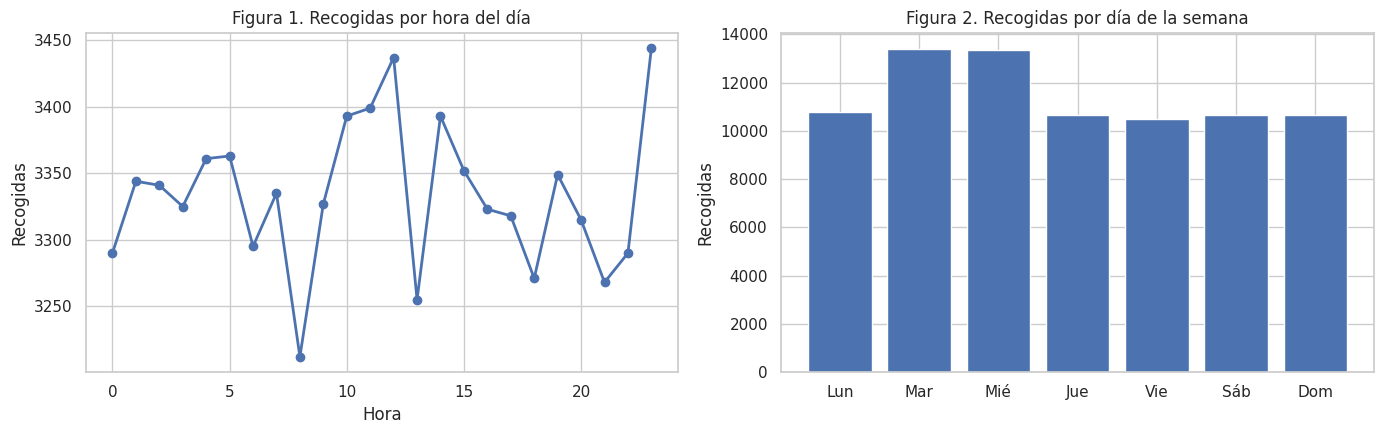

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

by_hour = df.groupby("hour").size()
axes[0].plot(by_hour.index, by_hour.values, marker="o", lw=2)
axes[0].set_title("Figura 1. Recogidas por hora del día")
axes[0].set_xlabel("Hora"); axes[0].set_ylabel("Recogidas")

dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
by_dow = df.groupby("dow").size()
axes[1].bar([dias[i] for i in by_dow.index], by_dow.values)
axes[1].set_title("Figura 2. Recogidas por día de la semana")
axes[1].set_ylabel("Recogidas")

plt.tight_layout(); plt.show()

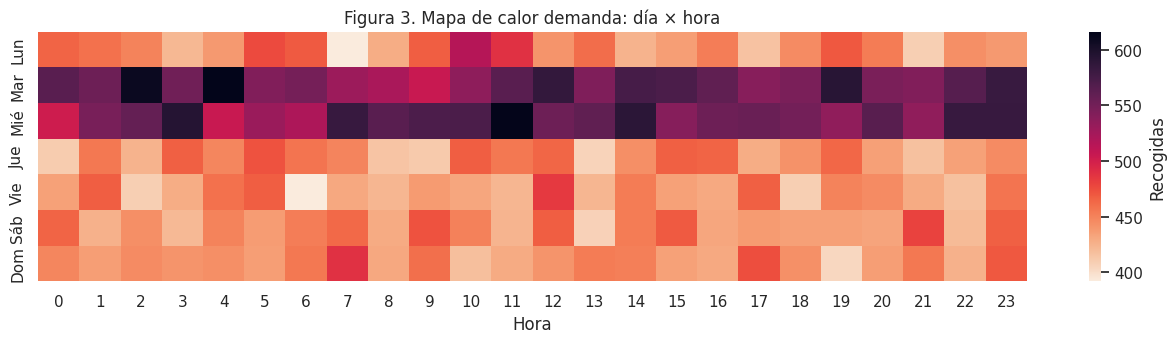

In [5]:
pivot = df.pivot_table(index="dow", columns="hour", values="Lat", aggfunc="size").fillna(0)
plt.figure(figsize=(13, 3.6))
sns.heatmap(pivot, cmap="rocket_r", cbar_kws={"label": "Recogidas"},
            yticklabels=dias)
plt.title("Figura 3. Mapa de calor demanda: día × hora")
plt.xlabel("Hora"); plt.ylabel("")
plt.tight_layout(); plt.show()

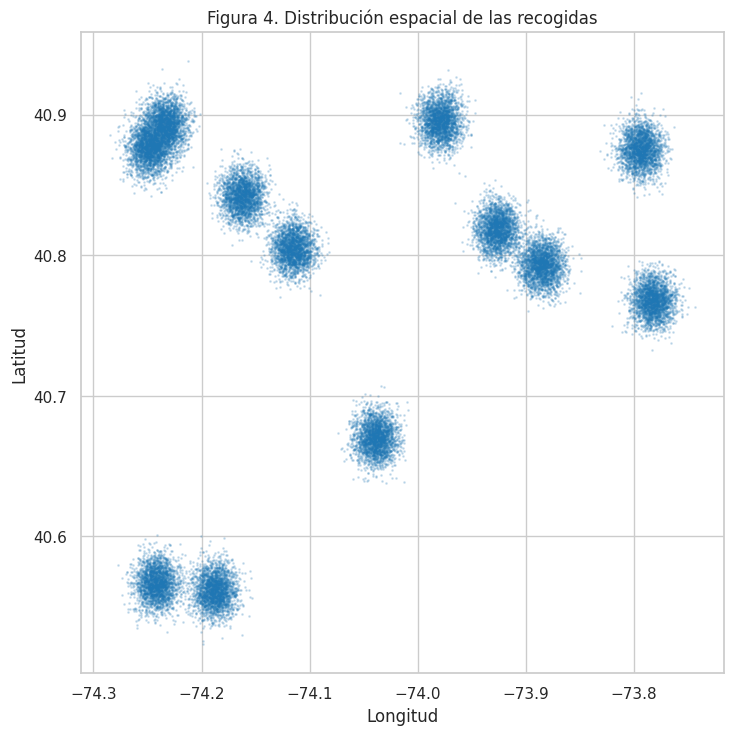

In [6]:
sample = df.sample(min(30_000, len(df)), random_state=RANDOM_STATE)
plt.figure(figsize=(7.5, 8))
plt.scatter(sample.Lon, sample.Lat, s=1, alpha=0.18, c="#1f77b4")
plt.title("Figura 4. Distribución espacial de las recogidas")
plt.xlabel("Longitud"); plt.ylabel("Latitud")
plt.gca().set_aspect(1.3)
plt.tight_layout(); plt.show()

## 3. Selección de K

Recorremos una rejilla de valores de K y elegimos por **coeficiente de
silueta**, reportando además la inercia (codo) para contrastar. La silueta se
calcula sobre una submuestra: su costo es cuadrático en el número de puntos y
sobre 400 000 registros no termina nunca.

In [7]:
X = df[D.FEATURES].to_numpy()
K_GRID = [3, 5, 8, 12] if USE_SYNTHETIC else list(range(15, 56, 5))

best_k, history = search_k(X, k_grid=K_GRID, seed=RANDOM_STATE)
hist = pd.DataFrame(history)
print(f"\nK seleccionado: {best_k}")
hist

  K=  3  silhouette=0.6481  inertia=593.09


  K=  5  silhouette=0.6624  inertia=241.03


  K=  8  silhouette=0.7732  inertia=47.32


  K= 12  silhouette=0.6841  inertia=15.60

K seleccionado: 8


,k,silhouette,inertia
0,3,0.648094,593.086687
1,5,0.662363,241.032604
2,8,0.773208,47.324396
3,12,0.684128,15.604737


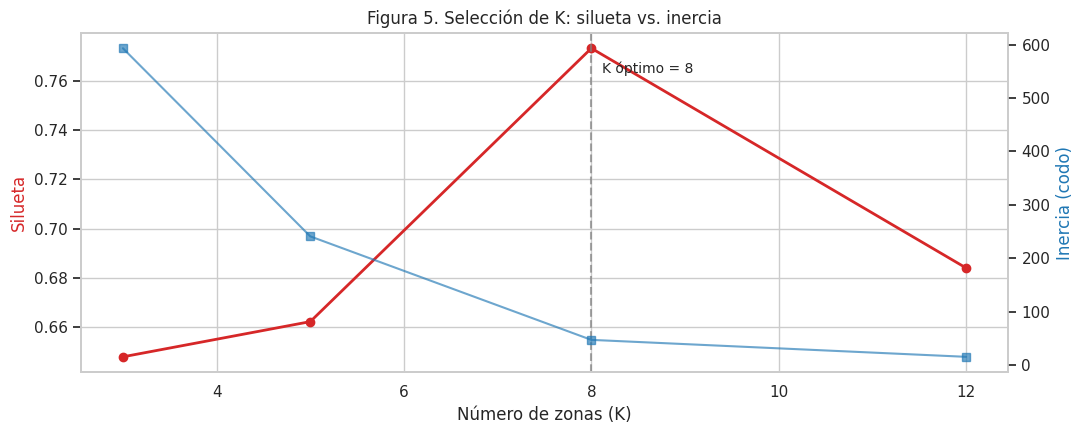

In [8]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(hist.k, hist.silhouette, marker="o", color="#d62728", lw=2, label="Silueta")
ax1.set_xlabel("Número de zonas (K)"); ax1.set_ylabel("Silueta", color="#d62728")
ax1.axvline(best_k, ls="--", c="gray", alpha=.7)
ax1.annotate(f"K óptimo = {best_k}", xy=(best_k, hist.silhouette.max()),
             xytext=(8, -18), textcoords="offset points", fontsize=10)

ax2 = ax1.twinx()
ax2.plot(hist.k, hist.inertia, marker="s", color="#1f77b4", alpha=.65, label="Inercia")
ax2.set_ylabel("Inercia (codo)", color="#1f77b4"); ax2.grid(False)

plt.title("Figura 5. Selección de K: silueta vs. inercia")
plt.tight_layout(); plt.show()

### Por qué MiniBatchKMeans y no DBSCAN

DBSCAN describiría mejor zonas de forma irregular, pero **no tiene `predict`**:
no puede asignar un punto nuevo sin reajustar todo el modelo. Eso rompe tanto el
servicio en línea como el reentrenamiento automático. Se evaluó igualmente como
contraste (ver informe técnico); para producción se eligió MiniBatchKMeans, que
escala a millones de puntos y sí soporta inferencia sobre datos nuevos.

## 4. Modelo final y zonas descubiertas

In [9]:
model = fit_final(X, best_k, seed=RANDOM_STATE)
labels = model.predict(X)

idx = np.random.default_rng(0).choice(len(X), size=min(20_000, len(X)), replace=False)
metrics = {
    "k": int(best_k),
    "silhouette": float(silhouette_score(X[idx], labels[idx])),
    "calinski_harabasz": float(calinski_harabasz_score(X[idx], labels[idx])),
    "davies_bouldin": float(davies_bouldin_score(X[idx], labels[idx])),
    "inertia": float(model.inertia_),
}
pd.Series(metrics).to_frame("valor")

,valor
k,8.000000
silhouette,0.771493
calinski_harabasz,193805.315232
davies_bouldin,0.318469
inertia,47.324363


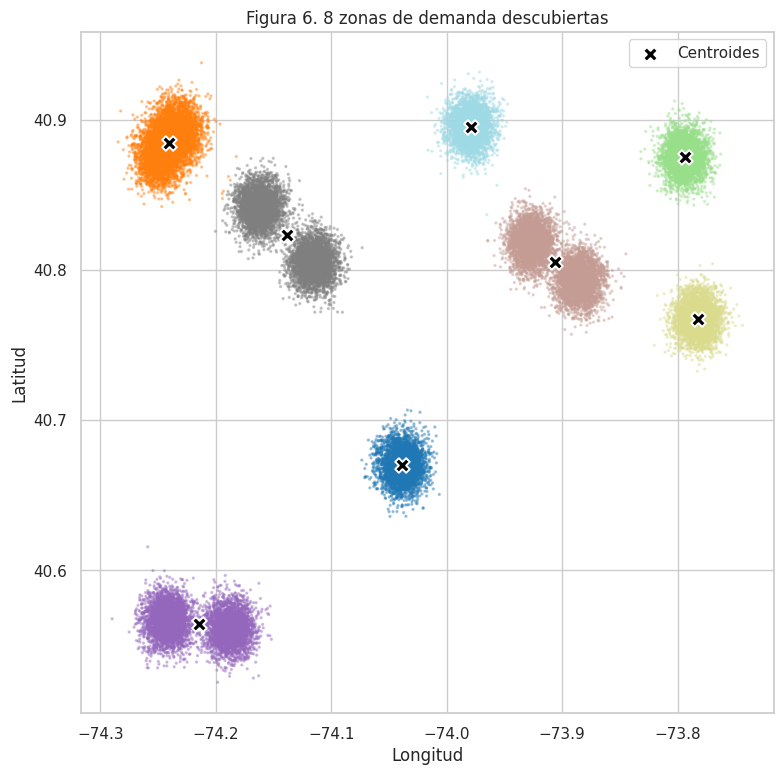

In [10]:
plt.figure(figsize=(8, 8.5))
s = np.random.default_rng(1).choice(len(X), size=min(40_000, len(X)), replace=False)
plt.scatter(X[s, 1], X[s, 0], c=labels[s], s=2, alpha=.35, cmap="tab20")
plt.scatter(model.cluster_centers_[:, 1], model.cluster_centers_[:, 0],
            c="black", s=110, marker="X", edgecolors="white", linewidths=1.4,
            label="Centroides")
plt.title(f"Figura 6. {best_k} zonas de demanda descubiertas")
plt.xlabel("Longitud"); plt.ylabel("Latitud"); plt.legend()
plt.gca().set_aspect(1.3)
plt.tight_layout(); plt.show()

## 5. Perfil de demanda: de clustering a producto

El clustering por sí solo no es una aplicación. Lo que la app consulta es esta
tabla: recogidas por `(zona, día, hora)`. **Debe regenerarse en cada
reentrenamiento**; si el modelo cambia y la tabla no, la interfaz mostraría
zonas que ya no existen.

In [11]:
profile = D.demand_profile(df, labels)
print(f"Filas del perfil: {len(profile):,}")

viernes_8pm = (profile[(profile.dow == 4) & (profile.hour == 20)]
               .sort_values("pickups", ascending=False).head(8))
cent = pd.DataFrame(model.cluster_centers_, columns=["Lat", "Lon"])
viernes_8pm.merge(cent, left_on="zone", right_index=True)

Filas del perfil: 1,344


,zone,dow,hour,pickups,Lat,Lon
788,4,4,20,88,40.805473,-73.905881
956,5,4,20,81,40.823296,-74.138770
620,3,4,20,78,40.563836,-74.214876
284,1,4,20,64,40.884725,-74.240778
1124,6,4,20,40,40.767208,-73.782691
116,0,4,20,40,40.669917,-74.038433
1292,7,4,20,28,40.895395,-73.979370
452,2,4,20,27,40.875283,-73.793759


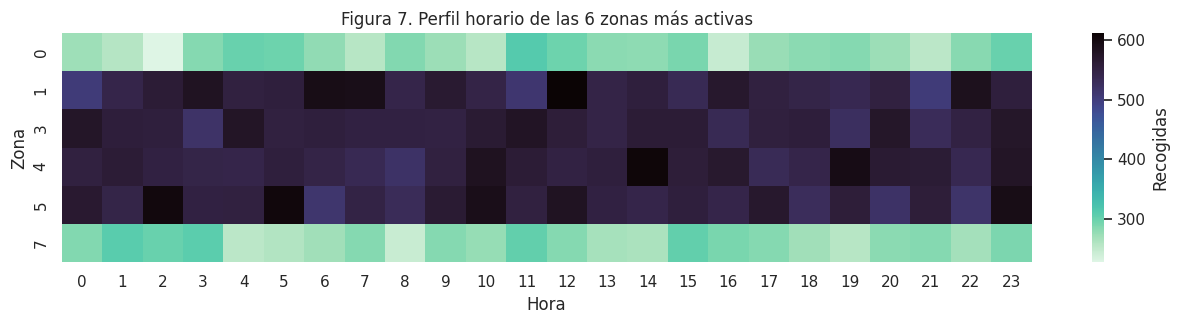

In [12]:
top = profile.groupby("zone").pickups.sum().nlargest(6).index
piv = (profile[profile.zone.isin(top)]
       .pivot_table(index="zone", columns="hour", values="pickups", aggfunc="sum")
       .fillna(0))
plt.figure(figsize=(13, 3.4))
sns.heatmap(piv, cmap="mako_r", cbar_kws={"label": "Recogidas"})
plt.title("Figura 7. Perfil horario de las 6 zonas más activas")
plt.xlabel("Hora"); plt.ylabel("Zona")
plt.tight_layout(); plt.show()

## 6. Experimento de deriva (drift)

Aquí se demuestra por qué el sistema necesita mantenimiento. Aplicamos el modelo
entrenado con abril–mayo sobre un lote posterior y medimos tres señales:

| Señal | Qué detecta |
|---|---|
| `silhouette_new_batch` | La calidad de las zonas sobre datos nuevos |
| `far_point_rate` | Recogidas que caen lejos de todo centroide — demanda en sitios nunca vistos |
| Desplazamiento de centroides | Cuánto se movería la geografía si reentrenáramos |

Si cualquiera cruza su umbral, el flujo de reentrenamiento se dispara solo.

In [13]:
from src import monitor

baseline = dict(metrics)
baseline["dist_p99"] = monitor.training_distance_p99(X, model)

if USE_SYNTHETIC:
    nuevo = D.make_synthetic_batch(40_000, n_zones=12, seed=99, shift=0.06)
    etiqueta = "lote sintético con deriva inyectada"
else:
    nuevo = D.load_months(["jun14"], sample=200_000)
    etiqueta = "junio 2014"

reporte = monitor.run(nuevo, baseline, model)
print(f"Lote evaluado: {etiqueta}")
print(json.dumps(reporte, indent=2))

Lote evaluado: lote sintético con deriva inyectada
{
  "silhouette_production": 0.771492586438195,
  "silhouette_new_batch": 0.35492883056260655,
  "relative_drop": 0.5399452479495209,
  "far_point_rate": 0.9278,
  "thresholds": {
    "sil_drop_pct": 0.15,
    "far_point_max": 0.1
  },
  "drift_detected": true,
  "reason": "silhouette drop"
}


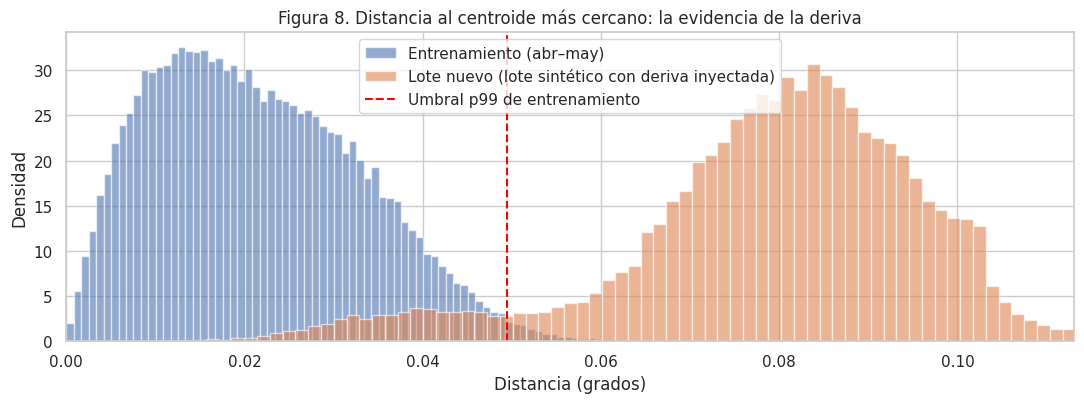

In [14]:
d_train = np.min(model.transform(X), axis=1)
d_new = np.min(model.transform(nuevo[D.FEATURES].to_numpy()), axis=1)

plt.figure(figsize=(11, 4.2))
plt.hist(d_train, bins=90, alpha=.6, density=True, label="Entrenamiento (abr–may)")
plt.hist(d_new, bins=90, alpha=.6, density=True, label=f"Lote nuevo ({etiqueta})")
plt.axvline(baseline["dist_p99"], ls="--", c="red",
            label="Umbral p99 de entrenamiento")
plt.title("Figura 8. Distancia al centroide más cercano: la evidencia de la deriva")
plt.xlabel("Distancia (grados)"); plt.ylabel("Densidad"); plt.legend()
plt.xlim(0, np.percentile(d_new, 99.5))
plt.tight_layout(); plt.show()

## 7. Reentrenamiento y compuerta de promoción

El modelo candidato **no reemplaza automáticamente** al de producción: solo lo
hace si mejora la métrica por encima de un margen mínimo. Ese `if` es lo que
convierte un script de entrenamiento en un proceso de mantenimiento.

In [15]:
df_ext = pd.concat([df, nuevo], ignore_index=True)
X_ext = df_ext[D.FEATURES].to_numpy()

candidato = fit_final(X_ext, best_k, seed=RANDOM_STATE)

sil_prod = evaluate(X_ext, model)["silhouette"]
sil_cand = evaluate(X_ext, candidato)["silhouette"]
ganancia = sil_cand - sil_prod

print(f"Silueta del modelo en producción sobre datos nuevos : {sil_prod:.4f}")
print(f"Silueta del modelo candidato                        : {sil_cand:.4f}")
print(f"Ganancia: {ganancia:+.4f}  (umbral requerido: +0.0050)")
print("\nDECISIÓN:", "PROMOVER ✅" if ganancia > 0.005 else "RECHAZAR ❌")

Silueta del modelo en producción sobre datos nuevos : 0.5456
Silueta del modelo candidato                        : 0.5766
Ganancia: +0.0311  (umbral requerido: +0.0050)

DECISIÓN: PROMOVER ✅


Desplazamiento promedio de centroides: 2.60 km


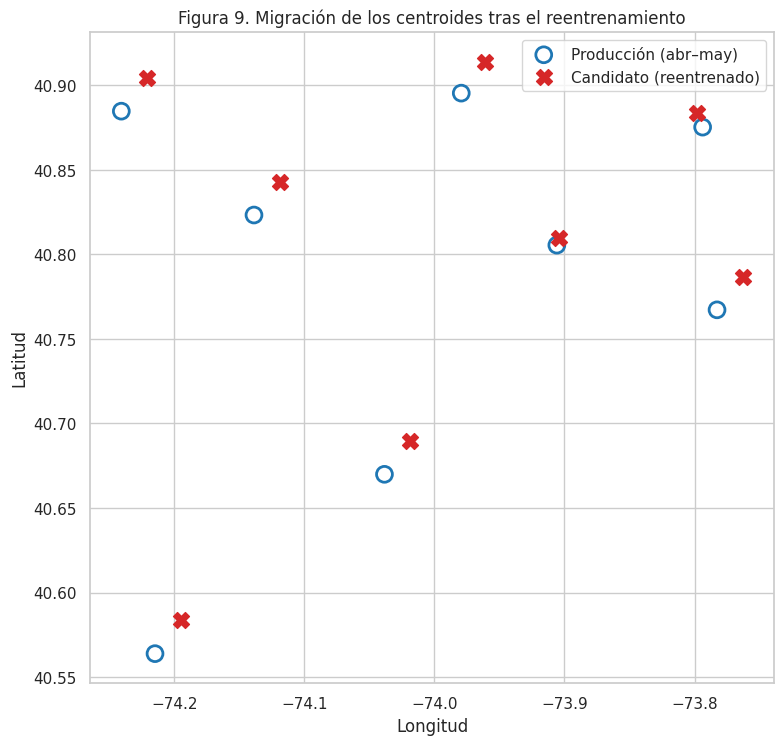

In [16]:
desplazamiento = np.linalg.norm(
    np.sort(candidato.cluster_centers_, axis=0) - np.sort(model.cluster_centers_, axis=0),
    axis=1,
).mean() * 111  # grados → km aproximados

print(f"Desplazamiento promedio de centroides: {desplazamiento:.2f} km")

plt.figure(figsize=(8, 8.5))
plt.scatter(model.cluster_centers_[:, 1], model.cluster_centers_[:, 0],
            s=130, marker="o", facecolors="none", edgecolors="#1f77b4",
            linewidths=2, label="Producción (abr–may)")
plt.scatter(candidato.cluster_centers_[:, 1], candidato.cluster_centers_[:, 0],
            s=130, marker="X", c="#d62728", label="Candidato (reentrenado)")
plt.title("Figura 9. Migración de los centroides tras el reentrenamiento")
plt.xlabel("Longitud"); plt.ylabel("Latitud"); plt.legend()
plt.gca().set_aspect(1.3)
plt.tight_layout(); plt.show()

## 8. Exportación de artefactos

Tres archivos salen de este notebook y son exactamente lo que consume la
aplicación desplegada. Deben versionarse juntos: un modelo sin su perfil de
demanda no sirve.

In [17]:
MODELS = Path("../models"); MODELS.mkdir(exist_ok=True)

joblib.dump(model, MODELS / "candidate.joblib")
metrics_out = dict(metrics)
metrics_out.update({
    "months": D.TRAIN_MONTHS,
    "dist_p99": baseline["dist_p99"],
    "k_search": history,
})
(MODELS / "candidate_metrics.json").write_text(json.dumps(metrics_out, indent=2))
D.save_processed(profile, model.cluster_centers_)

print("Artefactos generados:")
print("  models/candidate.joblib")
print("  models/candidate_metrics.json")
print("  data/processed/demand_profile.parquet")
print("  data/processed/centroids.csv")
print("\nSiguiente paso:  python -m src.promote")

Artefactos generados:
  models/candidate.joblib
  models/candidate_metrics.json
  data/processed/demand_profile.parquet
  data/processed/centroids.csv

Siguiente paso:  python -m src.promote


## 9. Conclusiones

1. El modelo descubre zonas de demanda **sin usar ninguna etiqueta**; la
   validación es interna (silueta, Calinski-Harabasz, Davies-Bouldin) porque no
   existe una verdad de referencia.
2. La marca de tiempo se mantiene deliberadamente fuera del modelo y se aplica
   después, lo que hace las zonas interpretables y el perfil horario reutilizable.
3. La deriva entre lotes mensuales es **medible y real**: no fue simulada con
   ruido, proviene del cambio estacional de la demanda.
4. La compuerta de promoción impide que un reentrenamiento degrade el servicio,
   que es el requisito central del mantenimiento en producción.

**Limitaciones.** K-Means impone zonas convexas de tamaño similar, lo que no
refleja la geometría real de un barrio. HDBSCAN daría formas más fieles a costa
de perder la inferencia directa sobre puntos nuevos. Los datos son de 2014 y no
representan la demanda actual.